In [216]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [217]:
# images load =>> Transform ==>> Dataset of all the images
class ImageProcessor:
    def __init__(self, root_dir_path, transformations = None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations
        
        # create a list of all the paths for the images

        self.all_imag_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_imag_paths)

    def __getitem__(self,idx):
        image_path= self.all_imag_paths[idx]
        img = Image.open(image_path).convert("RGB")

        if self.transformations:
            img =self.transformations(img)

        return img

In [218]:
root_dir_path= "./GANs/img_align_celeba"
transformations = transforms.Compose([
    transforms.CenterCrop(178), #==> 178*218 = 178*178
    transforms.Resize(64), # 64*64
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # [-1. 1]
                         ])

In [219]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [220]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Generative Network

In [221]:
import torch.nn as nn
import torch.optim as optim 
import numpy as np

In [222]:
class Generator(nn.Module):
    def __init__ (self, z_dim = 100, img_channels = 3): # z is the noise, image chanels are for RGB
        super(Generator, self).__init__()

        # fully connected(dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 ==>256
            nn.ReLU(), 

            nn.Linear(256, 512), 
            nn.ReLU(), 
            nn.Linear(512, 1024), 
            nn.ReLU(), 
            nn.Linear(1024, 64*64*img_channels), 
            nn.Tanh() # [-1, 1] to get tha same output as we transform our dataset images
        )

   
    def forward (self, z):
            img = self.model(z)
            img = img.view(img.size(0), 3, 64, 64) # .size(0) gives us the batch size, so here it generates the imgaes in batches
            return img
        # it returns a four dimmentions = 64*64*img_channel * batch_size
        

# Discriminator Network

In [223]:
class Discriminator(nn.Module):
    def __init__ (self, z_dim = 100, img_channels = 3): # z is the noise, image chanels are for RGB
        super(Discriminator, self).__init__()

        # fully connected(dense) layers
        
        self.model = nn.Sequential(
            nn.Flatten(), # here it converts the 4 dimmentional input to thte single dimmention for processing
            nn.Linear(64*64*img_channels, 1024), 
            nn.LeakyReLU(0.2, inplace=True), 

            nn.Linear(1024, 512), 
            nn.LeakyReLU(0.2, inplace = True), 
            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, inplace=True),  # inplece True means The activation modifies the input tensor directly instead of creating a new tensor
            nn.Linear(256, 1),
            nn.Sigmoid() # probability of being fake or real
        )

    def forward(self, img):
            return self.model(img)

In [224]:
discriminator = Discriminator()
generator = Generator()
GAN_loss = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr = 0.002, betas = (0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr = 0.002, betas = (0.5, 0.999))


In [225]:
# to select the device

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [226]:
generator = generator.to(device)
discriminator = discriminator.to(device)


# Train the GAN

In [227]:
def train (generator, discriminator, epochs = 10):

    for epoch in range (10):
        for i, image in enumerate(dataloader): # enumerate is used to the index
            real_imgs = image.to(device)
            batch_size = real_imgs.size(0)

            # creates real fake imgs labels

            real_labels = torch.ones(batch_size, 1).to(device) # [1,1,1...]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0,0,0...]

            # train the Discriminator
            d_optimizer.zero_grad()

            noise = torch.randn(batch_size, 100, device=device)
            fake_imgs = generator(noise)

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss)/2

            d_loss.backward()
            d_optimizer.step()

            # train the Generator 

            g_optimizer.zero_grad()
            
            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 ==0:
                print(f"for epocs: {epoch+1}/{epochs}... batch: {i+1}..... G_loss: {g_loss}... D_loss{d_loss}")
        # save the generated images for each epoc
        save_generated_images(generator, epoch, device)
            
        

In [228]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np

def save_generated_images(generator, epoch, device, num_imgs = 8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs= generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(grid.permute(1, 2, 0).numpy()) # this will convert the grid tensor(channel, H*W) to the matoplot(H*W*C)
    plt.title(f"epoch {epoch +1}")
    plt.axis("off")
    plt.show()


for epocs: 1/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.6680467128753662... D_loss0.6891900300979614
for epocs: 1/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.8600074052810669... D_loss1.3025038242340088
for epocs: 1/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.8434613347053528... D_loss0.41132503747940063
for epocs: 1/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.5523039102554321... D_loss0.44981855154037476
for epocs: 1/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.9047927856445312... D_loss0.37996140122413635
for epocs: 1/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 1/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epoc

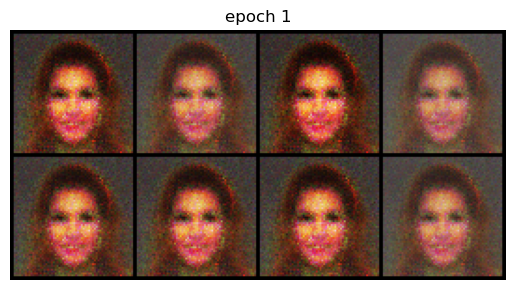

for epocs: 2/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 2/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 2/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 2/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 2/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.0
for epocs: 2/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 2/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 2/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 2/<torch.utils.data.data

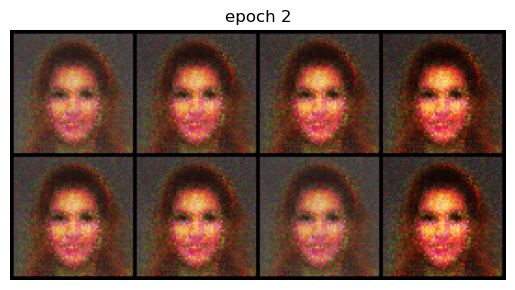

for epocs: 3/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 3/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 3/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 3/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 3/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.0
for epocs: 3/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 3/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 3/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 3/<torch.utils.data.data

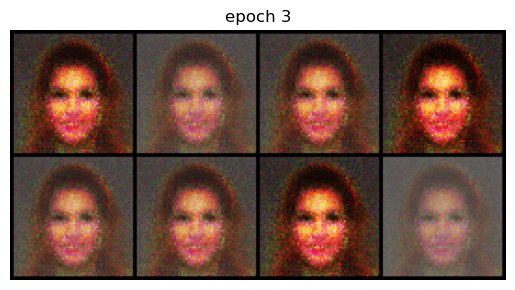

for epocs: 4/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 4/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 4/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 4/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 4/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.000003814697266
for epocs: 4/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 4/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 4/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 4/<torch.u

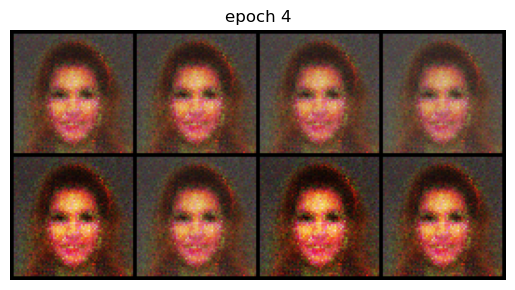

for epocs: 5/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 5/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 5/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 5/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 5/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.0
for epocs: 5/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 5/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 5/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 5/<torch.utils.data.data

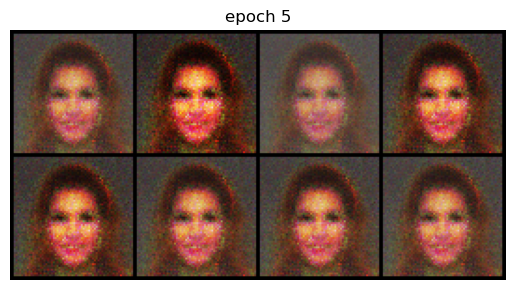

for epocs: 6/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 6/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 6/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 6/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 6/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.0
for epocs: 6/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 6/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 6/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 6/<torch.utils.data.data

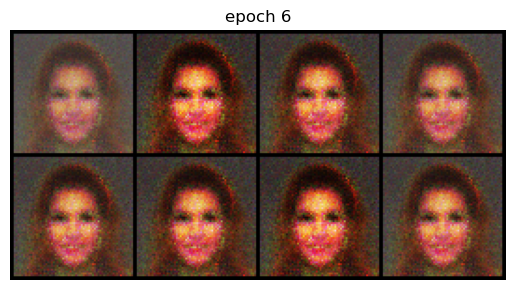

for epocs: 7/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 7/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 7/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 7/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 7/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.0
for epocs: 7/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 7/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 7/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 7/<torch.utils.data.data

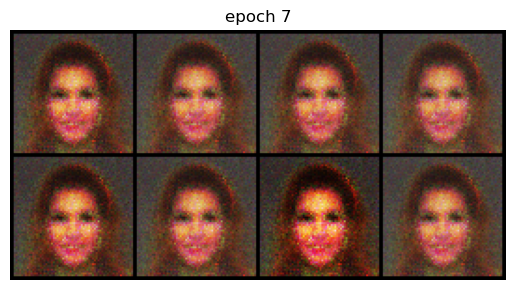

for epocs: 8/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 8/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 8/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 8/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 8/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.0
for epocs: 8/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 8/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 8/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 8/<torch.utils.data.data

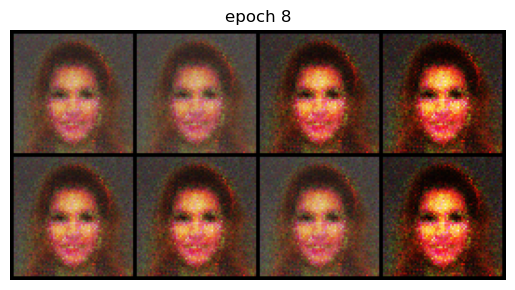

for epocs: 9/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 9/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 9/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 9/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 9/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.0
for epocs: 9/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 9/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 9/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 9/<torch.utils.data.data

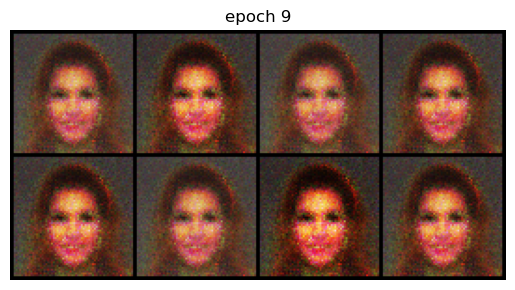

for epocs: 10/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 1..... G_loss: 0.0... D_loss50.0
for epocs: 10/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 51..... G_loss: 0.0... D_loss50.0
for epocs: 10/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 101..... G_loss: 0.0... D_loss50.0
for epocs: 10/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 151..... G_loss: 0.0... D_loss50.0
for epocs: 10/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 201..... G_loss: 0.0... D_loss50.0
for epocs: 10/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 251..... G_loss: 0.0... D_loss50.0
for epocs: 10/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 301..... G_loss: 0.0... D_loss50.0
for epocs: 10/<torch.utils.data.dataloader.DataLoader object at 0x16b26e850>... batch: 351..... G_loss: 0.0... D_loss50.0
for epocs: 10/<torch.utils.

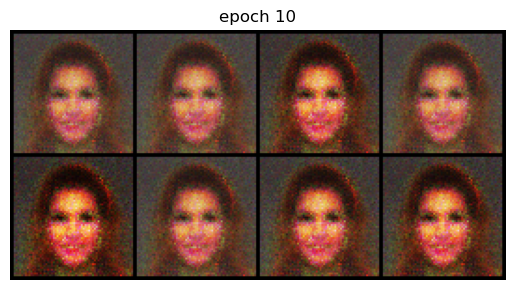

In [229]:
train(generator, discriminator, dataloader)